# house price clustering analysis with pca

**5*a by ahmed abobakr**

## project overview
this notebook demonstrates advanced clustering techniques to segment houses based on their features. we will use dimensionality reduction (pca & t-sne) and multiple clustering algorithms (k-means, dbscan, hierarchical) to identify distinct property groups.

## objectives
1.  **data preparation**: load and scale the data for clustering.
2.  **dimensionality reduction**: use pca and t-sne to visualize high-dimensional data.
3.  **optimal k**: determine the best number of clusters.
4.  **modeling**: apply k-means, dbscan, and hierarchical clustering.
5.  **evaluation**: compare models using silhouette score and davies-bouldin index.
6.  **profiling**: analyze and interpret the characteristics of each cluster.

---

## 1. import libraries & load data
importing necessary libraries and loading the preprocessed dataset.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("libraries imported successfully")

libraries imported successfully


In [10]:
# load data
df = pd.read_csv('models/processed_data.csv')
print(f"dataset shape: {df.shape}")
df.head()

dataset shape: (4600, 16)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,city,house_age,years_since_renovation,total_sqft,price_log
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,Shoreline,70,20,9252,12.653962
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,Seattle,104,0,12700,14.684291
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,Kent,59,0,13877,12.742569
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,Bellevue,62,0,10030,12.948012
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,Redmond,49,33,12440,13.217675


---

## 2. data preparation
selecting numerical features and scaling them for clustering.

In [11]:
# select features for clustering (numerical only)
feature_cols = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 
                'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
                'house_age', 'years_since_renovation', 'total_sqft']

X = df[feature_cols].copy()

# handle any missing values
X = X.fillna(X.median())

# scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("data scaled successfully")

data scaled successfully


---

## 3. dimensionality reduction
reducing dimensions using pca and t-sne to visualize the data structure in 2d.

In [12]:
# pca
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"pca explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# t-sne (using a subset for speed)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled[:1000])
print("t-sne transformation complete")

pca explained variance: 45.03%
t-sne transformation complete


---

## 4. determine optimal clusters
using the elbow method and silhouette scores to find the optimal number of clusters.

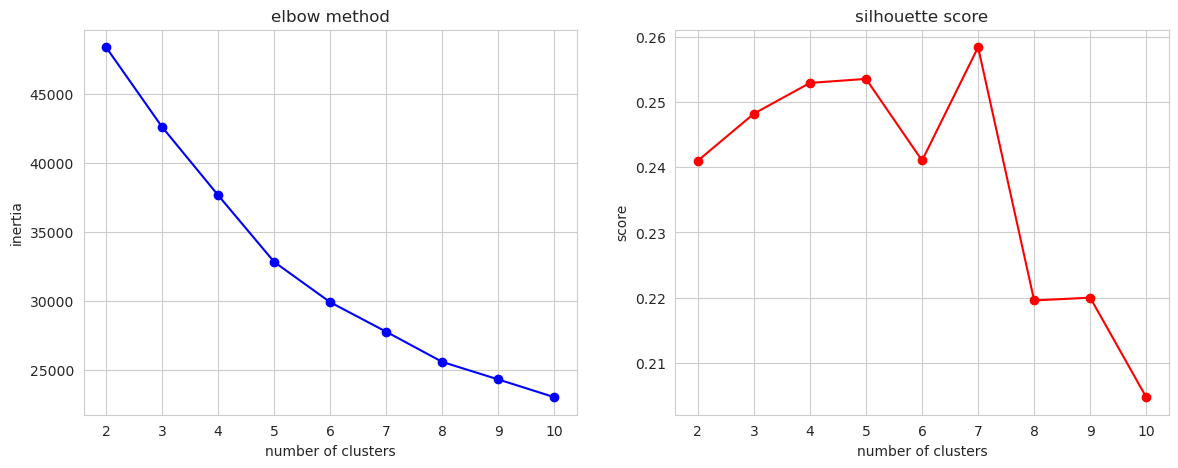

best k by silhouette: 7


In [13]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_title('elbow method')
ax1.set_xlabel('number of clusters')
ax1.set_ylabel('inertia')

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_title('silhouette score')
ax2.set_xlabel('number of clusters')
ax2.set_ylabel('score')

plt.show()
print(f"best k by silhouette: {K_range[np.argmax(silhouette_scores)]}")

---

## 5. clustering modeling
applying k-means, dbscan, and hierarchical clustering algorithms.

In [14]:
optimal_k = 4

# 1. k-means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

# 2. dbscan
dbscan = DBSCAN(eps=3, min_samples=10)
labels_dbscan = dbscan.fit_predict(X_scaled)

# 3. hierarchical
hierarch = AgglomerativeClustering(n_clusters=optimal_k)
labels_hierarch = hierarch.fit_predict(X_scaled)

print("clustering completed")

clustering completed


---

## 6. evaluation & comparison
comparing the performance of the three algorithms.

In [15]:
results = {
    'k-means': {
        'silhouette': silhouette_score(X_scaled, labels_kmeans),
        'davies-bouldin': davies_bouldin_score(X_scaled, labels_kmeans),
        'n_clusters': len(np.unique(labels_kmeans))
    },
    'dbscan': {
        'silhouette': silhouette_score(X_scaled, labels_dbscan) if len(np.unique(labels_dbscan)) > 1 else -1,
        'davies-bouldin': davies_bouldin_score(X_scaled, labels_dbscan) if len(np.unique(labels_dbscan)) > 1 else -1,
        'n_clusters': len(np.unique(labels_dbscan[labels_dbscan != -1]))
    },
    'hierarchical': {
        'silhouette': silhouette_score(X_scaled, labels_hierarch),
        'davies-bouldin': davies_bouldin_score(X_scaled, labels_hierarch),
        'n_clusters': len(np.unique(labels_hierarch))
    }
}

results_df = pd.DataFrame(results).T
print("clustering algorithm comparison:")
print(results_df)

clustering algorithm comparison:
              silhouette  davies-bouldin  n_clusters
k-means         0.252908        1.471505         4.0
dbscan          0.635627        1.698804         1.0
hierarchical    0.220442        1.298729         4.0


---

## 7. cluster profiling
analyzing the characteristics of each cluster identified by k-means.

cluster profiles (average values):
         bedrooms  bathrooms  sqft_living   sqft_lot  floors  waterfront  \
cluster                                                                    
0            3.07       1.65      1603.25    9940.29    1.13        0.00   
1            3.71       2.64      3271.50  231667.25    1.66        0.00   
2            3.58       2.61      2452.23   11173.75    2.04        0.00   
3            4.31       3.01      3476.89   15670.16    1.53        0.07   

         view  condition  sqft_above  sqft_basement  house_age  \
cluster                                                          
0        0.08       3.63     1286.09         317.04      71.20   
1        0.56       3.31     2951.56         319.94      43.74   
2        0.04       3.14     2371.15          81.93      29.07   
3        1.64       3.66     2405.47        1071.43      59.53   

         years_since_renovation  total_sqft      price  
cluster                                               

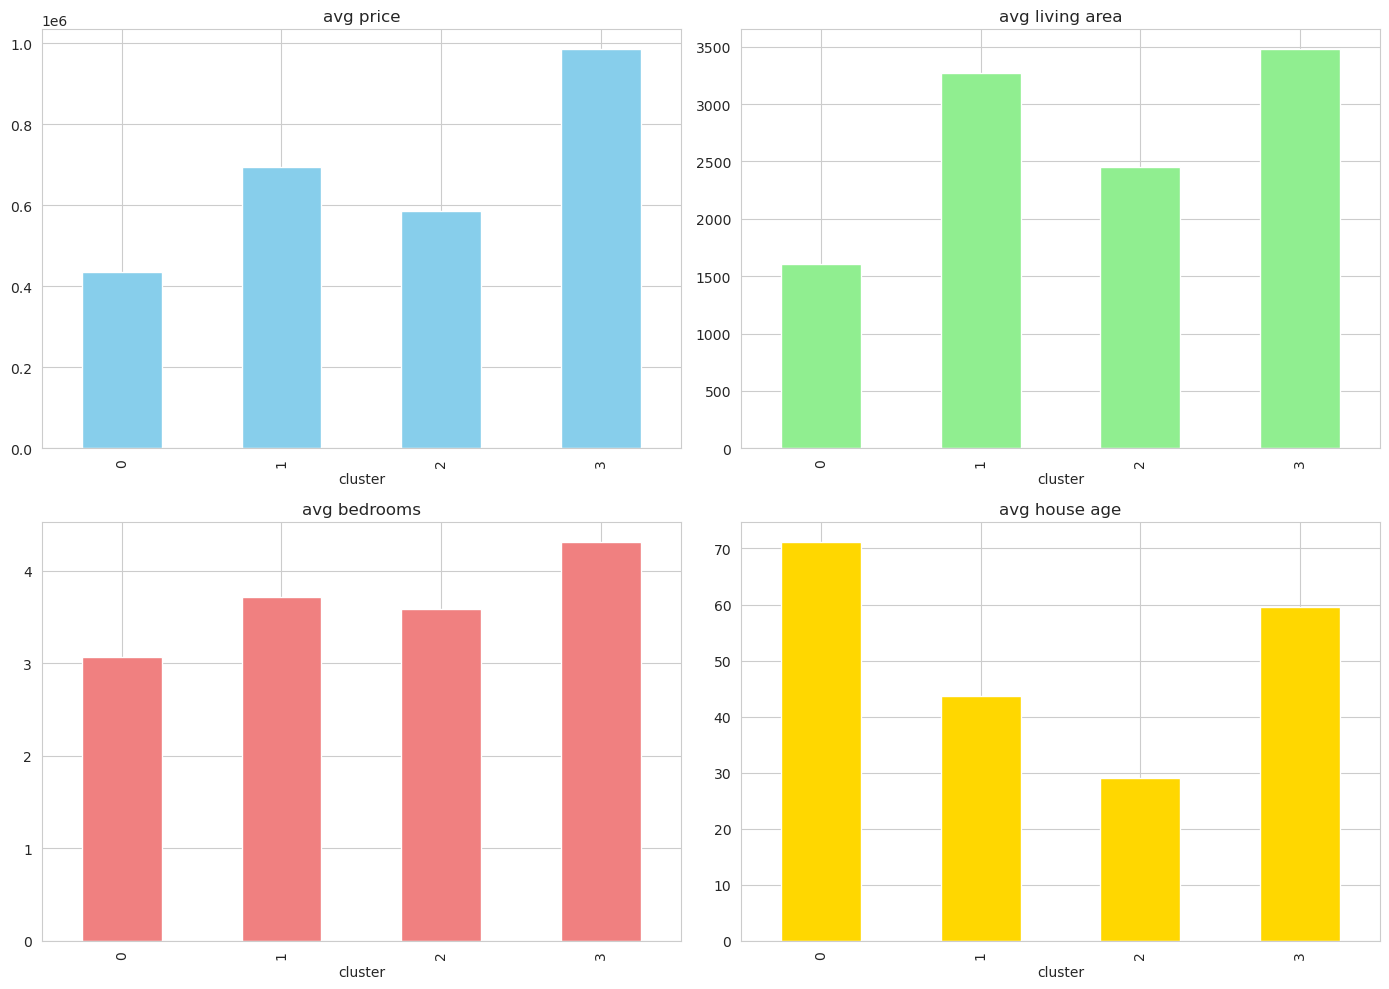

In [16]:
df_clustered = df[feature_cols].copy()
df_clustered['cluster'] = labels_kmeans
df_clustered['price'] = np.expm1(df['price_log'])

cluster_profiles = df_clustered.groupby('cluster').mean()
print("cluster profiles (average values):")
print(cluster_profiles.round(2))

# visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cluster_profiles['price'].plot(kind='bar', ax=axes[0,0], color='skyblue', title='avg price')
cluster_profiles['sqft_living'].plot(kind='bar', ax=axes[0,1], color='lightgreen', title='avg living area')
cluster_profiles['bedrooms'].plot(kind='bar', ax=axes[1,0], color='lightcoral', title='avg bedrooms')
cluster_profiles['house_age'].plot(kind='bar', ax=axes[1,1], color='gold', title='avg house age')
plt.tight_layout()
plt.show()

## conclusion

**5*a by ahmed abobakr**

we successfully identified distinct segments of houses. these clusters can help in understanding the market structure and pricing strategies.